In [3]:
import sys
from pathlib import Path

# 项目路径配置（使用绝对路径确保正确）
PROJECT_ROOT = Path(r"d:\Github\R4N_Gap_Predictor")
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

df = pd.read_excel(PROJECT_ROOT / "notebook" / "comparison.xlsx")
df

,Unnamed: 0,ZSO,ZSO-Br,N6111,N8111
0,Zn//Zn @ 1 mA cm,500.0,360.00,1800.00,2000.00
1,Zn//Zn @ 5 mA cm,44.0,30.00,76.00,180.00
2,Zn//Cu @ 1 mA cm,240.0,360.00,490.00,500.00
3,CE,98.8,99.31,99.47,99.53
4,Ratio (002),14.0,16.00,39.00,58.00


Saved to: d:\Github\R4N_Gap_Predictor\notebook\radar_chart.png


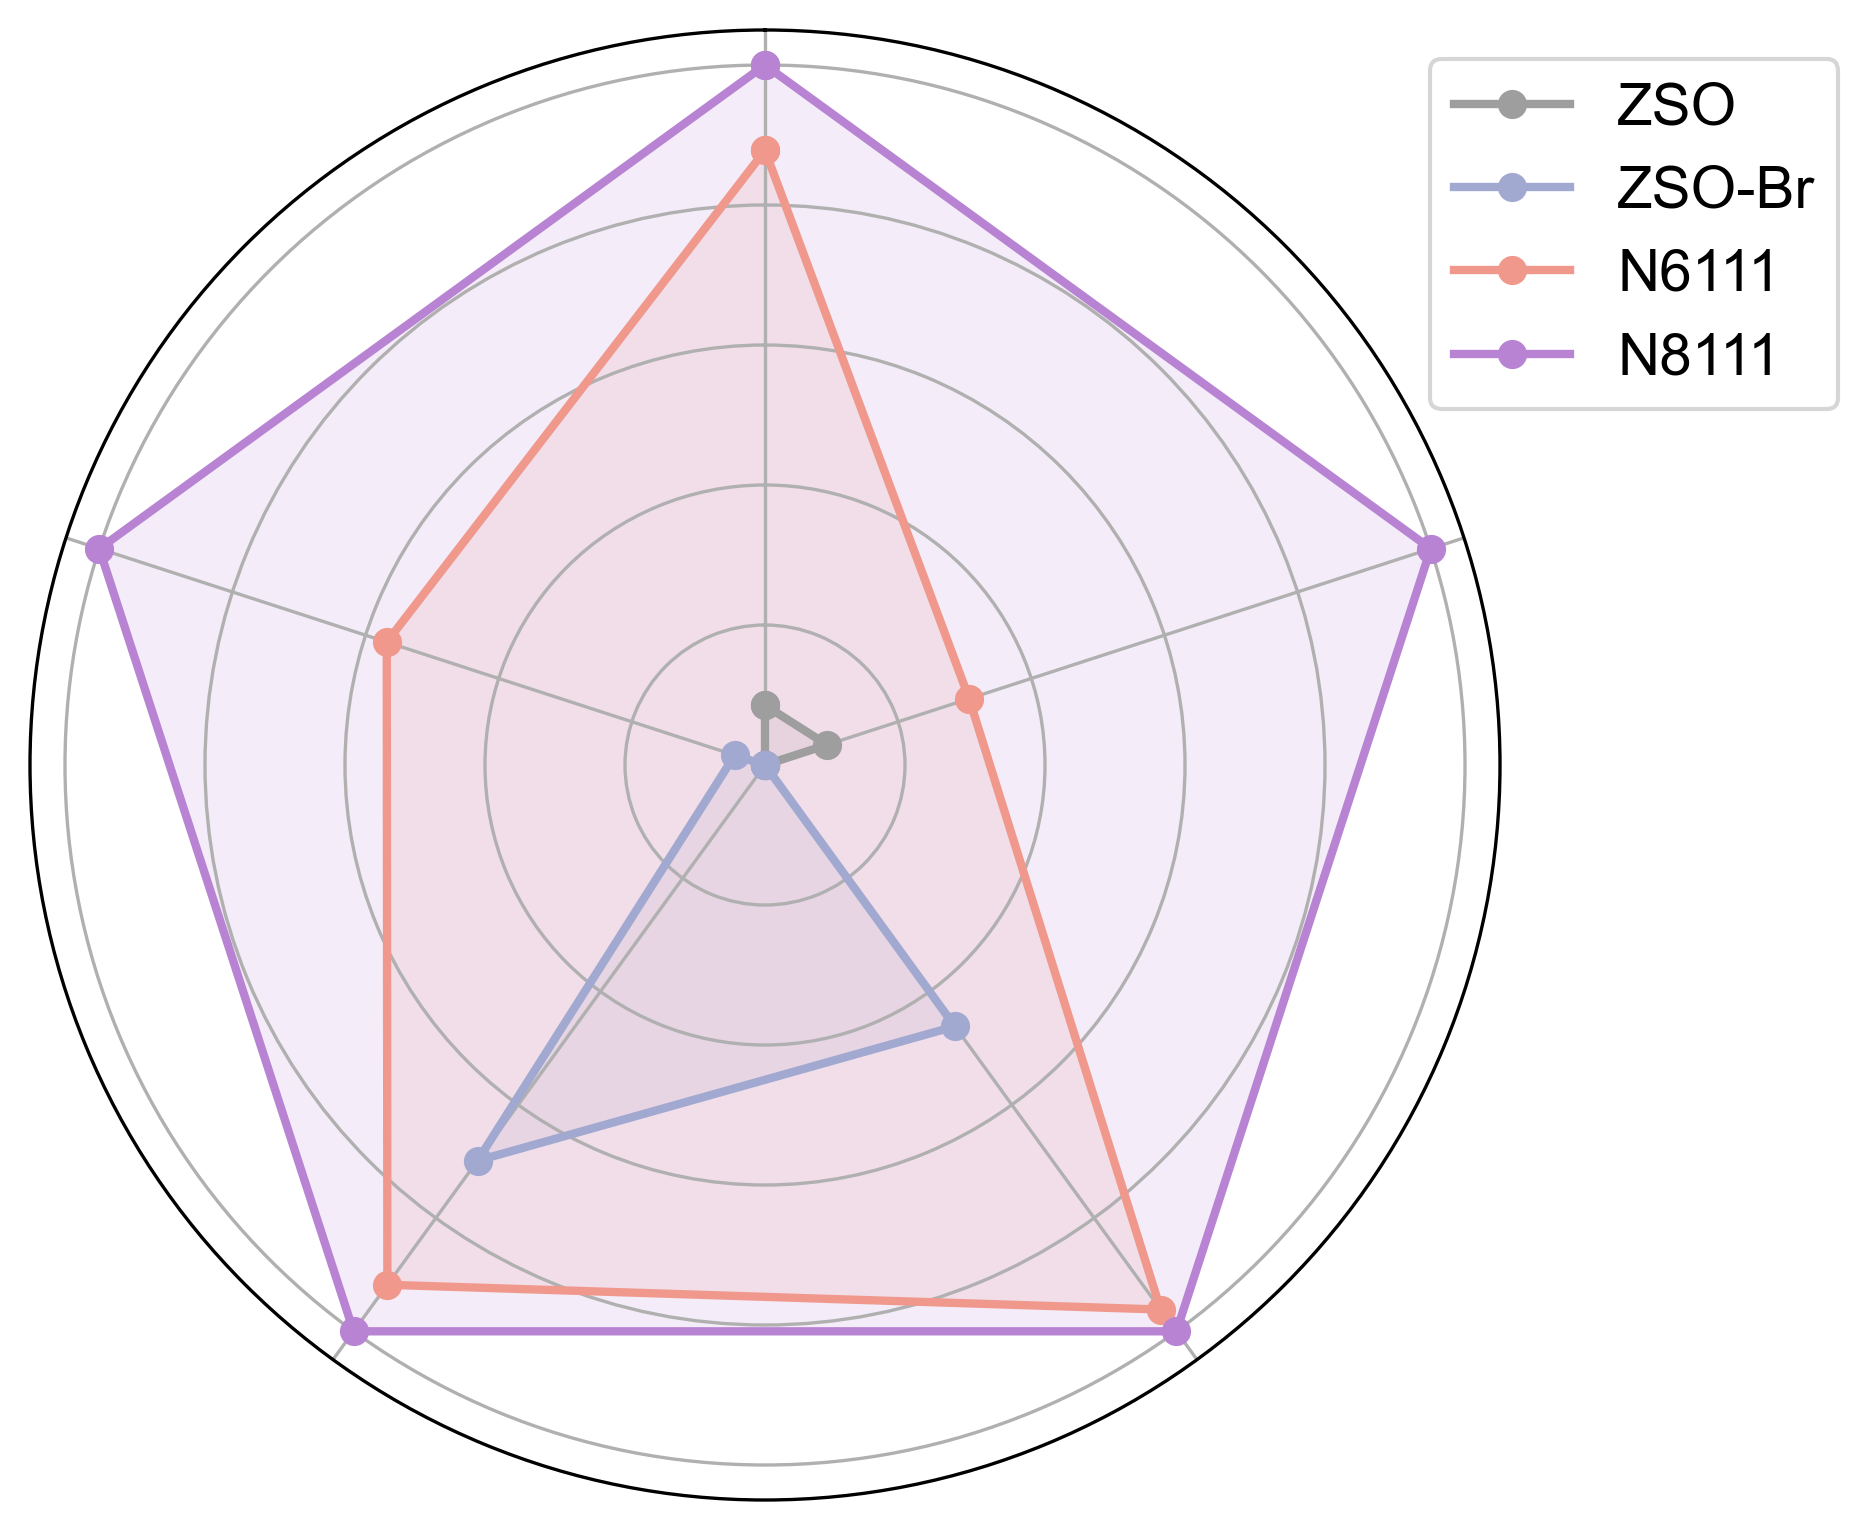

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 全局字体设置
plt.rcParams['font.family'] = 'Arial'

# 设置第一列为索引（指标名称）
df_plot = df.set_index('Unnamed: 0')

# 材料名称（列）
materials = df_plot.columns.tolist()

# 指标名称（行，作为雷达的5个维度）
metrics = df_plot.index.tolist()

# 前三行添加上标 -2
metrics_display = []
for i, m in enumerate(metrics):
    if i < 3 and 'cm' in m:
        metrics_display.append(m.replace('cm', 'cm$^{-2}$'))
    else:
        metrics_display.append(m)

# MinMax归一化：(x - min) / (max - min)
df_normalized = df_plot.apply(lambda row: (row - row.min()) / (row.max() - row.min()), axis=1)

# 雷达图绘制
N = len(metrics)  # 5个维度

# 计算角度
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

fig = plt.figure(figsize=(8, 7), dpi=300)

# 通过设置轴的位置来留出边距 [left, bottom, width, height]
ax = fig.add_axes([0.15, 0.15, 0.65, 0.7], polar=True)

# 设置第一个轴在顶部（90度位置）
ax.set_theta_offset(np.pi / 2)  # 起始角度偏移90度
ax.set_theta_direction(-1)  # 顺时针方向

# 设置只显示5条x网格线（角度方向的辐射线）
ax.set_xticks(angles[:-1])

# 自定义颜色列表
colors = ['#9E9E9E', '#A1A9D0', '#F0988C', '#B883D3']

# 为每个材料绘制雷达图
for idx, material in enumerate(materials):
    values = df_normalized[material].values.tolist()
    values += values[:1]  # 闭合图形
    
    ax.plot(angles, values, 'o-', linewidth=2, label=material, color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# 不显示x轴刻度和标签
ax.set_xticklabels([])
ax.set_yticklabels([])

# 设置5条y网格线（对应5个刻度）
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

# 设置图例
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.0), fontsize=14)

# 保存图片
save_path = PROJECT_ROOT / "notebook" / "radar_chart.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.3)
print(f"Saved to: {save_path}")

plt.show()